###Часть 1 — Семинар

Получим SNP файл выравнивания с  фильтром по 90% идентичности

In [ ]:
(base) bibizyana@LAPTOP-1QG8VVPK:~/genome_alignment_prac/results$ delta-filter -1 -i 90 ecoli_full.delta > ecoli_full_filt1.delta
(base) bibizyana@LAPTOP-1QG8VVPK:~/genome_alignment_prac/results$ show-coords -r ecoli_full_filt1.delta | wc -l
335
(base) bibizyana@LAPTOP-1QG8VVPK:~/genome_alignment_prac/results$ show-snps -Clr ecoli_full_filt1.delta > ecoli_snp.txt
(base) bibizyana@LAPTOP-1QG8VVPK:~/genome_alignment_prac/results$ head ecoli_snp.txt
/home/bibizyana/genome_alignment_prac/results/../data/ecoli_k12.fna /home/bibizyana/genome_alignment_prac/results/../data/ecoli_o157.fna
NUCMER

    [P1]  [SUB]  [P2]      |   [BUFF]   [DIST]  |  [LEN R]  [LEN Q]  | [FRM]  [TAGS]
========================================================================================
      58   G C   58        |        6       58  |  4641652  5498578  |  1  1  NC_000913.3       NC_002695.2
      64   T C   64        |        6       64  |  4641652  5498578  |  1  1  NC_000913.3       NC_002695.2
     228   . A   229       |        0      228  |  4641652  5498578  |  1  1  NC_000913.3       NC_002695.2
     228   . C   230       |        0      228  |  4641652  5498578  |  1  1  NC_000913.3       NC_002695.2
     228   . C   231       |        0      228  |  4641652  5498578  |  1  1  NC_000913.3       NC_002695.2

**Столбцы:**

P1 - позиция нуклеотида в ecoli_k12.fna

SUB - замена нуклеотида, вставка/делеция

P2 -  позиция нуклеотида в ecoli_o157.fna

BUFF - количество нуклеотидов вокруг варианта, учитываемое для контекста

DIST - расстояние (в нуклеотидах) от данного SNP до ближайшего конца выравнивающегося блока

LEN R - длина референсного генома (ecoli_k12.fna)

LEN Q - длина выравненного генома (ecoli_o157.fna)

FRM - рамка считывания для референса и выравненной последовательности (1-1 это  прямая цепь для обоих)

TAGS - имена последовательностей, между которыми найдено различие

###Часть 2 — Аннотация SNP

In [ ]:
pip install Bio

In [ ]:
from Bio import SeqIO
from Bio.Seq import Seq

gb_file = "U00096.3.gb"
snp_file = "ecoli_snp.txt"

#1 - загрузка генома
record = SeqIO.read(gb_file, "genbank")
genome_seq = record.seq
print(f"Геном загружен: {record.id}, длина {len(genome_seq)} bp")

Геном загружен: U00096.3, длина 4641652 bp


In [ ]:
#2 - строки с CDS складываем в отдельный список для дальнейшего
cds_features = []
for feature in record.features:
    if feature.type == "CDS":
        cds_features.append(feature)

cds_features.sort(key=lambda f: int(f.location.start))

In [ ]:
#3 - готовим данные для анализа snp
valid_bases = {"A", "C", "G", "T"} #для фильтрации только реальных нуклеотидных замен
def parse_snps(file):
    snps = []
    with open(file) as f:
        for line in f:
            if line.startswith("#") or line.strip() == "": #пропускаем ненужные строки
                continue
            parts = line.split()
            try:
                pos = int(parts[0])
            except ValueError:
                continue
            ref = parts[1] #извлекаем нуклеотид в референсе и нуклеотид замены
            alt = parts[2]
            if ref not in valid_bases or alt not in valid_bases: #проверяем что в строке присутствует реальная замена нд а не вставка\удаление
                continue
            snps.append((pos, ref, alt))

    return snps

snps = parse_snps(snp_file)
print(f"Всего замен: {len(snps)}")
print("Первые 5 SNP:", snps[:5])

Всего замен: 68920
Первые 5 SNP: [(58, 'G', 'C'), (64, 'T', 'C'), (393, 'T', 'G'), (559, 'T', 'C'), (588, 'G', 'A')]


In [ ]:
#4 - функция, которая позволит нам  проверить влияние каждой snp на белок
def translate_codon(codon):
    return str(Seq(codon).translate()) #переводим кодон в аминокислоту


In [ ]:
#5 - анализ
complement = {"A": "T", "T": "A", "G": "C", "C": "G"} #словарь для получения комплементарного нуклеотида минус цепи
results = []

for pos, ref, alt in snps:
    found = False
    pos_0 = pos - 1 #выравниваем индексы
    for cds in cds_features:
        start = int(cds.location.start) #начало и конец гена
        end = int(cds.location.end)
        strand = cds.location.strand #определяем + или - цепь

        if start <= pos_0 < end:  #проверяем попадает ли snp в этот ген
            found = True
            gene = cds.qualifiers.get("gene", ["unknown"])[0]
            seq = cds.extract(genome_seq)

            if strand == 1:
                rel_pos = pos_0 - start
                alt_in_strand = alt
            else:
                rel_pos = end - 1 - pos_0
                alt_in_strand = complement.get(alt, alt)

            codon_start = (rel_pos // 3) * 3 #определяем начало кодона
            if codon_start + 3 > len(seq):
                continue

            ref_codon = list(str(seq[codon_start:codon_start + 3])) #берем референсный кодон как список букв
            pos_in_codon = rel_pos % 3 #находим позицию snp внутри кодона
            new_codon = ref_codon.copy() #копируем ref кодон и заменяем нужную букву на alt аллель
            new_codon[pos_in_codon] = alt_in_strand

            aa_old = translate_codon("".join(ref_codon)) #смотрим на изменение ак
            aa_new = translate_codon("".join(new_codon))
            if aa_old == aa_new:
                snp_type = "синонимичный"
            else:
                snp_type = "несинонимичный"

            aa_position = rel_pos // 3 + 1  #номер ак в белке
            aa_change = f"p.{aa_old}{aa_position}{aa_new}" #записываем название

            if aa_new == "*":  #если заменился на стоп кодон
                effect = "приобретение стоп-кодона"
            elif aa_old == "*":
                effect = "потеря стоп-кодона"
            elif snp_type == "синонимичный":
                effect = "низкое влияние"
            else:
                effect = "непредсказуемый"

            results.append((pos, gene, snp_type, aa_change, effect))
            break

    if not found:
        results.append((pos, "межгенный", "-", "-", "-"))

In [ ]:
#6 - результаты
import pandas as pd
df = pd.DataFrame(results, columns=["Позиция", "Ген", "Тип SNP","Замена аминокислоты", "Функциональный эффект"])
print(df.head(10))

   Позиция        Ген       Тип SNP Замена аминокислоты Функциональный эффект
0       58  межгенный             -                   -                     -
1       64  межгенный             -                   -                     -
2      393       thrA  синонимичный              p.R19R        низкое влияние
3      559       thrA  синонимичный              p.L75L        низкое влияние
4      588       thrA  синонимичный              p.G84G        низкое влияние
5      621       thrA  синонимичный              p.D95D        низкое влияние
6      669       thrA  синонимичный             p.L111L        низкое влияние
7      690       thrA  синонимичный             p.I118I        низкое влияние
8      774       thrA  синонимичный             p.T146T        низкое влияние
9      828       thrA  синонимичный             p.T164T        низкое влияние


In [ ]:
# @title
gene_snps = df[df["Ген"] != "межгенный"] #берем только cds
top_genes = gene_snps["Ген"].value_counts().head(15).reset_index() #кол-во snp на каждый ген
top_genes.columns = ["Ген", "Количество SNP"]

print("\nТоп-15 генов с наибольшим количеством SNP:")
print(top_genes.to_string(index=False))


Топ-15 генов с наибольшим количеством SNP:
 Ген  Количество SNP
ybgQ             430
yeeJ             250
ybgO             218
yehI             191
ybgP             165
yjgL             139
yfaL             139
entF             131
metH             109
evgS             109
putA             108
eamA             106
yccE             105
lacZ             103
 lhr             101


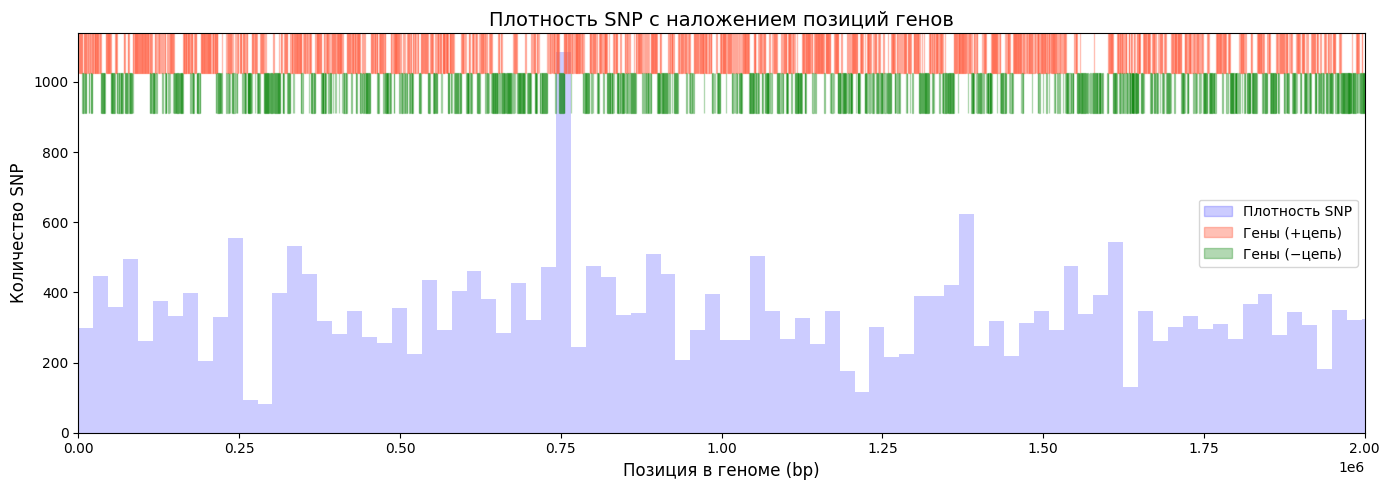

In [ ]:
# @title
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(14, 5))


all_positions = [pos for pos, *_ in results]

ax.hist(all_positions, bins=200, color="blue", alpha=0.2, label="Плотность SNP")
y_plus  = ax.get_ylim()[1] * 0.05
y_minus = ax.get_ylim()[1] * 0.02

for cds in cds_features:
    start  = int(cds.location.start)
    end    = int(cds.location.end)
    strand = cds.location.strand
    if strand == 1:
        ax.axvspan(start, end, ymin=0.90, ymax=1.0, color="tomato", alpha=0.4)
    else:
        ax.axvspan(start, end, ymin=0.80, ymax=0.90, color="green", alpha=0.3)


ax.set_xlim(0, 2_000_000)
ax.set_xlabel("Позиция в геноме (bp)", fontsize=12)
ax.set_ylabel("Количество SNP", fontsize=12)
ax.set_title("Плотность SNP с наложением позиций генов", fontsize=14)

snp_patch   = mpatches.Patch(color="blue",      alpha=0.2, label="Плотность SNP")
plus_patch  = mpatches.Patch(color="tomato",          alpha=0.4, label="Гены (+цепь)")
minus_patch = mpatches.Patch(color="green",  alpha=0.3, label="Гены (−цепь)")
ax.legend(handles=[snp_patch, plus_patch, minus_patch], fontsize=10)
plt.tight_layout()
plt.show()

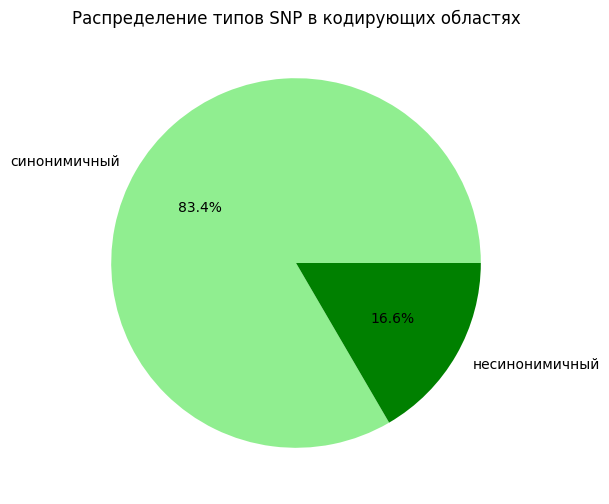

In [ ]:
# @title
import matplotlib.pyplot as plt

snp_counts = df[df["Тип SNP"] != "-"]["Тип SNP"].value_counts() #берем только cds
plt.figure(figsize=(6, 6))
plt.pie(snp_counts, labels=snp_counts.index, autopct='%1.1f%%', colors=['lightgreen','green'])
plt.title("Распределение типов SNP в кодирующих областях")
plt.show()

###Часть 3 — Поиск функционально значимых SNP

Рассмотрим [статью]( https://pmc.ncbi.nlm.nih.gov/articles/PMC11137339/), в которой описывается как E. coli адаптируется к стрессу через мутации

В частности SNP между K-12 и O157:H7 отражают эволюционную адаптацию к патогенному образу жизни

1)   В середине первого/начале второго раздела говорится о том,что nsSNP реже синонимичных, но функционально значимее,тк именно они влияют на функции белка

>Ratib et al. analyzed the genomic mutations in E. coli under nutrient stress and observed 679 mutations including 147 nsSNPs

Из 679 мутаций - 147 несинонимичные, что составляет 21%. Это близко к нашим полученным 17% nsSNP из 2 части задания

2)    Рассмотрим топ генов по количеству nsSNP


In [ ]:
# @title
# Топ генов с несинонимичными SNP
ns_snps = df[(df["Тип SNP"] == "несинонимичный") & (df["Ген"] != "межгенный")]

top_ns_genes = ns_snps["Ген"].value_counts().head(10).reset_index()
top_ns_genes.columns = ["Ген", "Количество нsSNP"]

print("\nТоп-10 генов с наибольшим количеством nsSNP:")
print(top_ns_genes.to_string(index=False))


Топ-10 генов с наибольшим количеством nsSNP:
 Ген  Количество нsSNP
ybgQ               118
yeeJ               114
yjgL                95
yehI                83
yccE                69
ybgO                61
ybgP                59
yfaL                57
yfdF                51
elaD                48


Большинство этих генов кодируют белки, участвующие либо в адгезии и образовании биопленок (yeeJ, yfaL), либо в синтезе фимбрий - белковых структур на поверхности бактериальных клеток (ybgO, ybgP, yehI), либо в делении клеток в процессе разделения мембран (ybgQ)

>Several genes exhibiting an abundance of non-synonymous mutations have become permanently fixed. These genes facilitate the production of type I fimbriae, including fimH, fimG, fimB, fimE, proQ and lsrK. The production of type I fimbriae is an essential factor that enables E. coli to form biofilms

Наши результаты согласуются с результатами в статье, гены адгезии и плёнкообразования наиболее обогащены nsSNP

Можно отметить, что штамм K-12 растет в условии лаборатории и ему не нужно прикрепляться ни к чему, в то время как  O157:H7 живёт в кишечнике человека и ему необходимо удержаться на эпителии. Поэтому именно гены адгезии накопили максимальное количество различий между штаммами

3)   Ген entF

Ген кодирует фермент, учавствующий в сборке энтеробактина (переносчика железа, обладающего цитопротекторной активностью против окислительного стресса, вызванного нагреванием)
> The heat shock response is a major defense mechanism used by
bacteria to cope with sudden increase in temperature. Kim et al.
studied the changes in mRNA in the E. coli cells at different time points
after rising the temperature to 42 ℃. When heat stress persists, gene expression levels can be slowly stabilized. Thus, genes that are overexpressed
in late stage might be involved in conferring heat tolerance to E. coli

В эксперименте, приведеном в статье, гены кластера kps (entCEB, entD, fes-entF) активировались исключительно на поздней стадии теплового стресса, когда клетка переходит от экстренной защиты к долгосрочной адаптации. Это свидетельствует о том что энтеробактин является частью механизма долгосрочного выживания в стрессовых условиях

В нашей работе высокое число SNP в entF (131) у O157:H7 по сравнению с K-12 как раз может отражать адаптацию этой защитной системы к условиям организма человека, где бактерия подвергается одновременно окислительному стрессу со стороны иммунных клеток и температурным изменениям при воспалительной реакции

4)   Наличие SNP в гене evgS

Рассмотриим в статье Таблицу 2.Транскриптомные изменения генов при разнообразном отборе

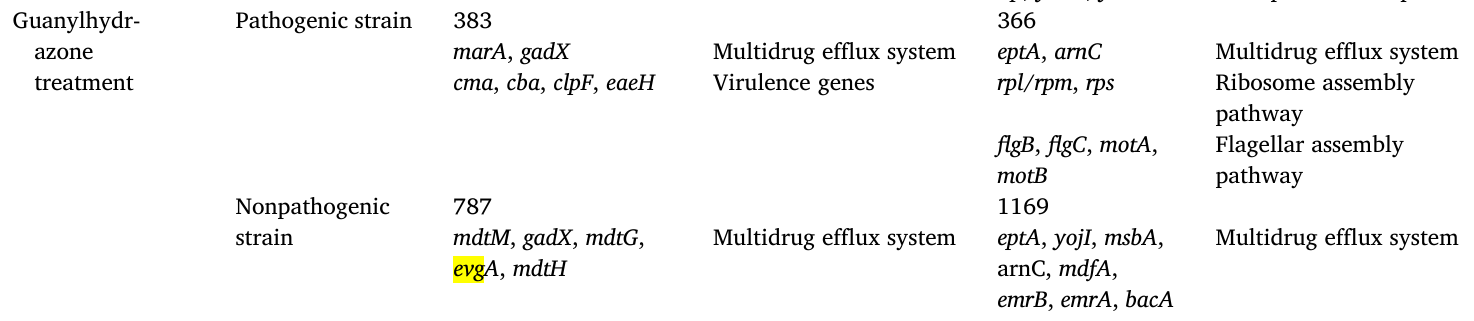

Бактерии обрабатывались гуанилгидразоном(токсин, который подавляет экспрессию рибосомных генов и генов жгутиков). По таблице мы видим что непатогенный штамм в ответ начинает экспрессировать ген evgA, который составляет регуляторную систему с evgS

EvgS/EvgA — двухкомпонентная система сигнальной трансдукции, с помощью которой бактерия чувствует изменение pH окружающей среды или добавление токсина/антибиотика. S-домен является сигнальной киназой, встроенной в мембрану. A-домен это регулятор ответа, который запускает транскрипцию своих генов-мишеней эффлюксных насосов (белковые комплексы в мембране которые захватывают токсичные вещества внутри клетки и выкачивают их наружу используя энергию протонного градиента)

Возможные причины накопления 109 SNP у патогенного штамма
*   Исходный evgS у лаборатороного штамма K-12 настроен на соответствующие условия — нейтральная среда, нет антибиотиков и токсинов. Мутации в сенсорном домене evgS у O157:H7 могли снизить порог активации системы. То есть система EvgS/EvgA у патогена включается быстрее и при более слабом стрессе чем у K-12
*   Статья показывает, что непатогенный штамм отвечает на стресс через evgA, а патогенный использует другие пути ⇒ в процессе эволюции O157:H7 перестроил всю регуляторную сеть. Мутации в evgS могли изменить также и то какие гены он в итоге активирует через EvgA
